In [1]:
from _utils_ import *
import tensorflow as tf

2025-04-21 19:48:35.462749: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2025-04-21 19:48:35.462772: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2025-04-21 19:48:35.462776: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.00 GB
2025-04-21 19:48:35.462791: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-04-21 19:48:35.462802: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [2]:
model = tf.keras.models.load_model('resnet_fusion_model.keras')

In [3]:
train_mic, train_us, train_labels, \
test_mic,  test_us,  test_labels = load_data(
    mic_dir="MIES_data_2/Mic/CHUNKS",
    us_dir ="MIES_data/US/CHUNKS"
)

print("Train:", train_mic.shape, train_labels.shape)  # (100,), (100,)
print("Test: ", test_mic.shape,  test_labels.shape)   # (10,) , (10,)

# build your mapping
label2idx = {lbl: i for i, lbl in enumerate(primary_order)}

train_labels = np.array([ label2idx[l] for l in train_labels ], dtype=np.int32)
test_labels  = np.array([ label2idx[l] for l in test_labels  ], dtype=np.int32)


Train: (100,) (100,)
Test:  (10,) (10,)


In [9]:
train_mic[0]

'MIES_data_2/Mic/CHUNKS/Forward_Chunks/TimeSeriesMic_forward_harish_chunk19.mat'

In [4]:
train_ds = tf_dataloader(
    mic_paths=train_mic,
    us_paths=train_us,
    labels=train_labels,
    batch_size=16,
    shuffle=True,
)
test_ds = tf_dataloader(
    mic_paths=test_mic,
    us_paths=test_us,
    labels=test_labels,
    batch_size=10,
    shuffle=False,
)

In [5]:
# callbacks
es = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)
ckpt = ModelCheckpoint(
    "best_model_2.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

# train
history = model.fit(
    train_ds,
    epochs=50,
    validation_data=test_ds,
    callbacks=[es, ckpt]
)

# final evaluation
loss, acc = model.evaluate(test_ds)
print(f"Test loss: {loss:.4f}, accuracy: {acc:.4%}")

Epoch 1/50


/opt/anaconda3/envs/dl_env/lib/python3.9/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['input_layer_6', 'input_layer_7']. Received: the structure of inputs=('*', '*')
  warnings.warn(
2025-04-21 19:48:40.370347: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 529ms/step - accuracy: 0.7984 - loss: 0.7698
Epoch 1: val_loss improved from inf to 0.06827, saving model to best_model_2.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 685ms/step - accuracy: 0.8048 - loss: 0.7503 - val_accuracy: 1.0000 - val_loss: 0.0683
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.9611 - loss: 0.1907
Epoch 2: val_loss improved from 0.06827 to 0.03174, saving model to best_model_2.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 524ms/step - accuracy: 0.9610 - loss: 0.1931 - val_accuracy: 1.0000 - val_loss: 0.0317
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.9604 - loss: 0.1258
Epoch 3: val_loss improved from 0.03174 to 0.03141, saving model to best_model_2.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 511ms/step - accuracy: 0.9603 - loss: 0.1251 - val_accuracy: 1.0000 - val_loss: 0.0314
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.9712 - loss: 0.0872
Epoch 4: val_loss improved from 0.03141 to 0.01192, saving model to best_

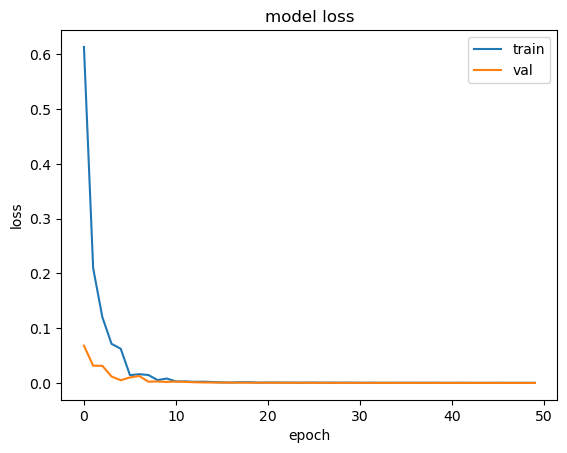

In [6]:
# plot loss curve from training
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend()
plt.show()

In [7]:
for (mic, us), label in test_ds.take(1):
    pred = model.predict((mic, us))
    pred = np.argmax(pred, axis=1)
    print("Predicted:", pred)
    print("True:     ", label.numpy())
    print("Label:    ", [primary_order[i] for i in label.numpy()])
    print("Pred:     ", [primary_order[i] for i in pred])

/opt/anaconda3/envs/dl_env/lib/python3.9/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['input_layer_6', 'input_layer_7']. Received: the structure of inputs=('*', '*')
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
Predicted: [0 0 1 1 2 2 3 3 4 4]
True:      [0 0 1 1 2 2 3 3 4 4]
Label:     ['power', 'power', 'forward', 'forward', 'backward', 'backward', 'up', 'up', 'down', 'down']
Pred:      ['power', 'power', 'forward', 'forward', 'backward', 'backward', 'up', 'up', 'down', 'down']


2025-04-21 19:52:20.108047: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
model.save("resnet_fusion_model_2.keras")